# Bài tập 02: Khám phá Hành vi và Sở thích Khách hàng Thương mại Điện tử

## Phần I: Định nghĩa Tập dữ liệu và Bài toán
- **Tên tập dữ liệu Kaggle**: Women's Clothing E-Commerce Reviews
- **Đặc trưng**: Dữ liệu bảng kết hợp văn bản đánh giá (`Review Text`).
- **Mục tiêu**: Dự đoán sự hài lòng/sở thích của khách hàng (`Recommended IND` hoặc Rating).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_ecommerce = pd.read_csv('Womens Clothing E-Commerce Reviews.csv')
print("Kích thước dataframe ban đầu:", df_ecommerce.shape)
display(df_ecommerce.head())
df_ecommerce.info()


Kích thước dataframe ban đầu: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB


## Phần II & III: Kiểm tra và Làm sạch Dữ liệu
Xử lý giá trị thiếu trên cột văn bản đánh giá.

In [9]:
# Kiểm tra số lượng giá trị thiếu (missing values) trước khi xử lý
print("Số lượng giá trị thiếu trên từng cột:")
print(df_ecommerce.isnull().sum())
print("-" * 40)

# Xử lý giá trị thiếu văn bản
df_ecommerce['Review Text'] = df_ecommerce['Review Text'].fillna('')
df_ecommerce = df_ecommerce.dropna(subset=['Recommended IND'])

print("Kích thước sau khi làm sạch:", df_ecommerce.shape)

Số lượng giá trị thiếu trên từng cột:
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                   0
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64
----------------------------------------
Kích thước sau khi làm sạch: (23486, 11)


## Phần IV: Biểu diễn Dữ liệu Văn bản (Bài giảng 02)
Chuyển đổi văn bản thô $\rightarrow$ Mã thông báo $\rightarrow$ TF-IDF / Embeddings $E \in \mathbb{R}^{B \times T \times d}$.

Kích thước ma trận đặc trưng văn bản sau TF-IDF: (23486, 1000)


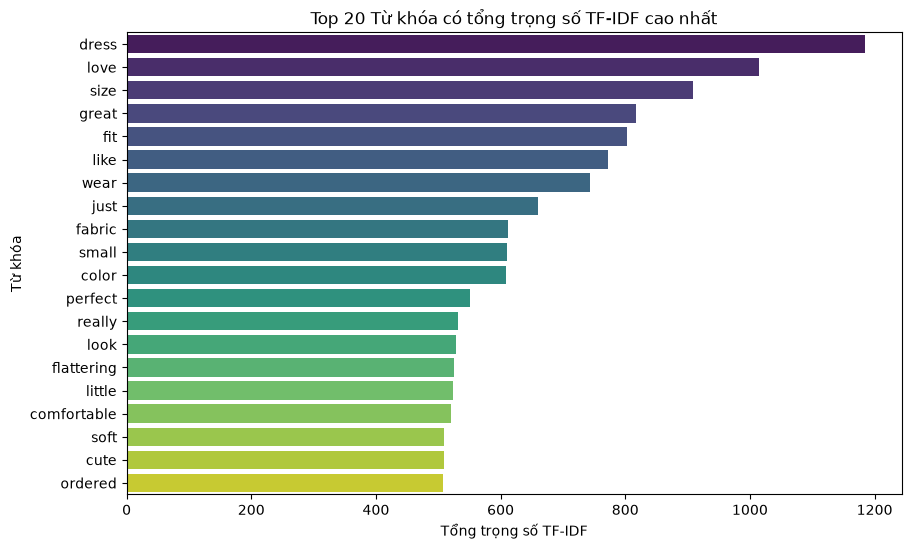

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
text_features = vectorizer.fit_transform(df_ecommerce['Review Text'])

print(f"Kích thước ma trận đặc trưng văn bản sau TF-IDF: {text_features.shape}")

# Biểu đồ Top 20 từ khóa quan trọng nhất theo tổng trọng số TF-IDF
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tính tổng trọng số TF-IDF của từng từ trên toàn bộ tập dữ liệu
sum_tfidf = text_features.sum(axis=0).A1
feature_names = vectorizer.get_feature_names_out()

# Tạo DataFrame lưu từ và trọng số
df_tfidf_scores = pd.DataFrame({'Term': feature_names, 'TF-IDF Score': sum_tfidf})
df_tfidf_scores = df_tfidf_scores.sort_values(by='TF-IDF Score', ascending=False).head(20)

# Vẽ biểu đồ ngang
plt.figure(figsize=(10, 6))
sns.barplot(x='TF-IDF Score', y='Term', data=df_tfidf_scores, hue='Term', palette='viridis', legend=False)
plt.title('Top 20 Từ khóa có tổng trọng số TF-IDF cao nhất')
plt.xlabel('Tổng trọng số TF-IDF')
plt.ylabel('Từ khóa')
plt.show()

## Phần V: Phân tích Khám phá Dữ liệu (EDA)
Phân phối điểm đánh giá và tỷ lệ giới thiệu sản phẩm.

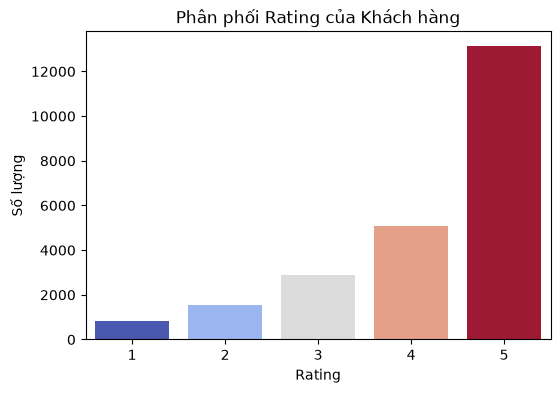

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Rating', data=df_ecommerce, hue='Rating', palette='coolwarm', legend=False)
plt.title('Phân phối Rating của Khách hàng')
plt.xlabel('Rating')
plt.ylabel('Số lượng')
plt.show()

# Quan sát: Đa số khách hàng đánh giá ở mức cao (4 và 5 sao).
# Diễn giải: Khách hàng có xu hướng tích cực hoặc sản phẩm đạt chất lượng tốt.
# Ý nghĩa học máy: Mô hình cần học các đặc trưng từ từ ngữ tích cực/tiêu cực để phân loại chính xác mức độ quan tâm.


## Phần VI: Phân chia Dữ liệu
Phân chia theo tỷ lệ 80% huấn luyện, 20% kiểm tra.

In [5]:
from sklearn.model_selection import train_test_split

X_ecomm = text_features
y_ecomm = df_ecommerce['Recommended IND']

X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(
    X_ecomm, y_ecomm, test_size=0.2, random_state=42, stratify=y_ecomm
)
print("Kích thước tập huấn luyện văn bản:", X_tr_e.shape)
print("Kích thước tập kiểm tra văn bản:", X_te_e.shape)


Kích thước tập huấn luyện văn bản: (18788, 1000)
Kích thước tập kiểm tra văn bản: (4698, 1000)


## Phần VII & VIII: Phát triển và Đánh giá 6 Mô hình
So sánh 6 mô hình: Logistic Regression, Decision Tree, Random Forest, SVM, Naive Bayes, và Gradient Boosting.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

ecomm_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=30),
    "SVM": SVC(),
    "Naive Bayes": MultinomialNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

ecomm_results = []
trained_ecomm_models = {}

for name, clf in ecomm_models.items():
    clf.fit(X_tr_e, y_tr_e)
    y_pred = clf.predict(X_te_e)
    
    acc = accuracy_score(y_te_e, y_pred)
    prec = precision_score(y_te_e, y_pred, zero_division=0)
    rec = recall_score(y_te_e, y_pred, zero_division=0)
    f1 = f1_score(y_te_e, y_pred, zero_division=0)
    
    ecomm_results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1})
    trained_ecomm_models[name] = clf

df_ecomm_res = pd.DataFrame(ecomm_results)
display(df_ecomm_res)


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.888250,0.899856,0.972301,0.934677
1,Decision Tree,0.816305,0.883828,0.894124,0.888946
2,Random Forest,0.866326,0.879072,0.971007,0.922755
3,SVM,0.887825,0.901154,0.969972,0.934297
4,Naive Bayes,0.855045,0.855134,0.991716,0.918375
5,Gradient Boosting,0.861218,0.864142,0.986280,0.921180


## Phần IX: So sánh Mô hình & Biện minh lựa chọn
Lựa chọn Logistic Regression hoặc SVM kết hợp TF-IDF làm mô hình tối ưu.

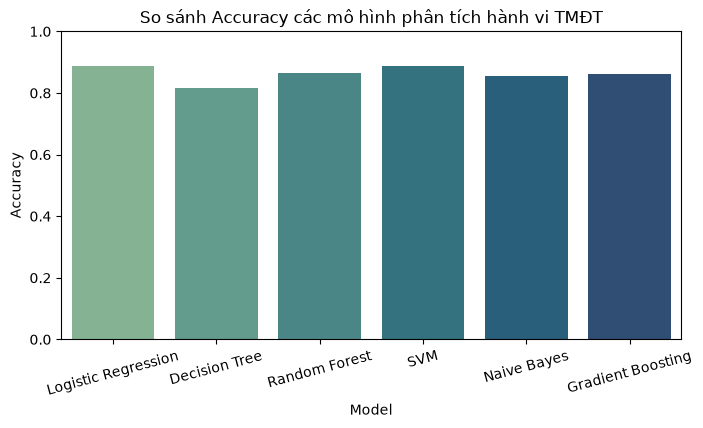

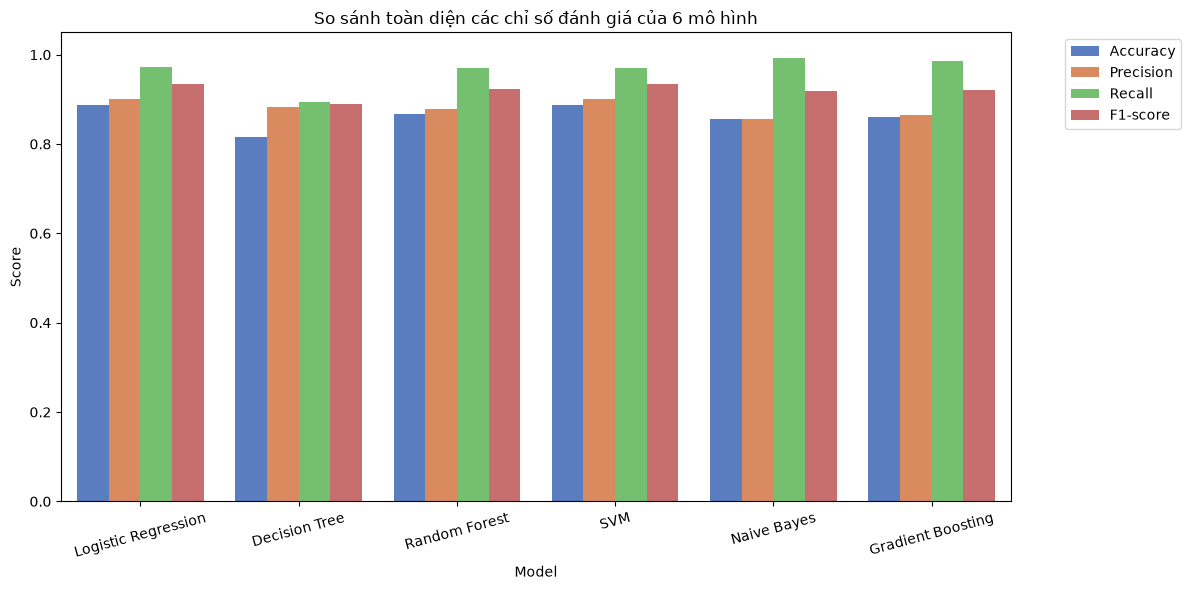

In [7]:
plt.figure(figsize=(8, 4))
sns.barplot(x='Model', y='Accuracy', data=df_ecomm_res, hue='Model', palette='crest', legend=False)
plt.title('So sánh Accuracy các mô hình phân tích hành vi TMĐT')
plt.ylim(0, 1.0)
plt.xticks(rotation=15)
plt.show()

# Chuyển đổi DataFrame kết quả sang dạng dài (long-form) để vẽ biểu đồ nhóm (grouped bar chart)
df_melted = pd.melt(
    df_ecomm_res, 
    id_vars=['Model'], 
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score'],
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='muted')
plt.title('So sánh toàn diện các chỉ số đánh giá của 6 mô hình')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Phần X: Lưu trữ Mô hình (Persistence)
Lưu vectorizer và mô hình tốt nhất.

In [8]:
import joblib

best_ecomm_clf = trained_ecomm_models["Logistic Regression"]
joblib.dump((vectorizer, best_ecomm_clf), "ecomm_model_pipeline.joblib")
print("Đã lưu pipeline mô hình Thương mại điện tử thành công vào 'ecomm_model_pipeline.joblib'")


Đã lưu pipeline mô hình Thương mại điện tử thành công vào 'ecomm_model_pipeline.joblib'
